In [19]:
import numpy as np
import matplotlib.pyplot as plt
import PcmPy as pcm

plt.style.use('default')

In [20]:
Z_stimFinger = np.zeros((13, 3))
Z_stimFinger[0:5, 0] = 1
Z_stimFinger[5:9, 1] = 1
Z_stimFinger[9:13, 2] = 1

Z_cue = np.zeros((13, 5))
Z_cue[[0,9], 0] = 1
Z_cue[[1,5,10], 1] = 1
Z_cue[[2,6,11], 2] = 1
Z_cue[[3,7,12], 3] = 1
Z_cue[[4,8], 4] = 1

Z1 = np.concatenate((Z_stimFinger, Z_cue), axis=1)

# make random orthonormal matrix Q
A = np.random.randn(8, 8)
Q, R = np.linalg.qr(A)

# check that QtQ = I
I = np.matmul(Q.T, Q)

Z2 = np.matmul(Z1, Q)


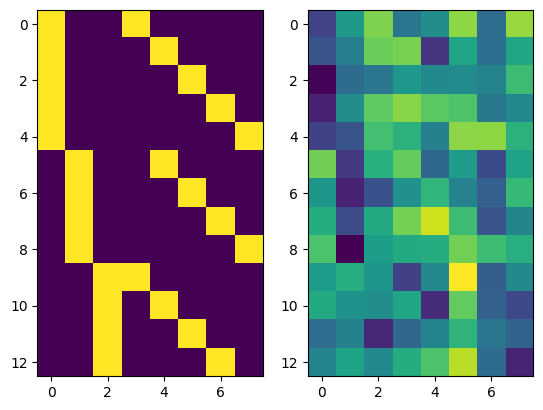

In [21]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(Z1)
axs[1].imshow(Z2)

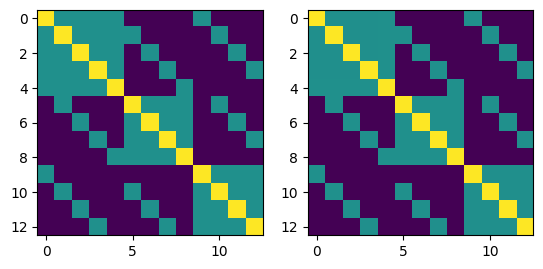

In [22]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(Z1 @ Z1.T)
axs[1].imshow(Z2 @ Z2.T)

In [40]:
import numpy as np

# Define the vector
v = np.array([-2, 1, 0, 1, 2])

# Compute the outer product
C = np.outer(v, v) + 1e-6 * np.eye(5)

# Compute standard deviations (sqrt of diagonal elements)
std_dev = np.sqrt(np.diag(C))

# Compute the normalization factor for each element
C_normalized = C / np.outer(std_dev, std_dev)

# Print the result
print("Normalized Covariance (Correlation) Matrix:\n", C_normalized)


Normalized Covariance (Correlation) Matrix:
 [[ 1.         -0.99999938  0.         -0.99999938 -0.99999975]
 [-0.99999938  1.          0.          0.999999    0.99999938]
 [ 0.          0.          1.          0.          0.        ]
 [-0.99999938  0.999999    0.          1.          0.99999938]
 [-0.99999975  0.99999938  0.          0.99999938  1.        ]]


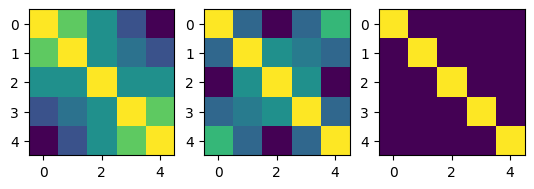

In [78]:
C = pcm.centering(5)

v_cue =  C @ np.array([-2, -1, 0, 1, 2]) 
v_cert = C @ np.array([0, 1, 2, 1, 0])

G_cue = np.outer(v_cue, v_cue)
np.fill_diagonal(G_cue, np.diag(G_cue).max())

G_cert = np.outer(v_cert, v_cert)
np.fill_diagonal(G_cert, np.diag(G_cert).max())

fig, axs = plt.subplots(1, 3)

axs[0].imshow(G_cue)
axs[1].imshow(G_cert)
axs[2].imshow(np.eye(5))